# Exact SPH boundary integrals in 2D by edge reductions

The kernel integral over a polygon is a **1D integral over its edges** plus an indicator (divergence theorem):

$$\int_T W\,dA=\mathbb 1[x\in T]+\sum_e z_e\!\int_{\rm chord}\frac{M(r)-M(1)}{r^2}ds,\qquad
\nabla_x\!\int_T W=-\sum_e n_e\!\int_{\rm chord}W\,ds .$$

This notebook shows (1) what the identities compute, (2) exactness on the validation problems of Winchenbach & Kolb 2025, (3) the conditioning remedies (stage 3 / FEM),
(4) the tier map for a curved obstacle. Everything is generated by `src/warpSPHBoundaries`; derivations and Maple proofs are in `docs/derivations/`.

In [1]:

import sys, pathlib, time
root = pathlib.Path.cwd()
root = root if (root / "python").exists() else root.parent
sys.path.insert(0, str(root / "python")); sys.path.insert(0, str(root / "tests"))
import numpy as np, matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline
from warpSPHBoundaries.edge import np2d, np_fem, tier_select
from warpSPHBoundaries.edge import fem_study


## 1. The value and the gradient field of one triangle (w4, h = 1, closed form, 4 µs per evaluation)

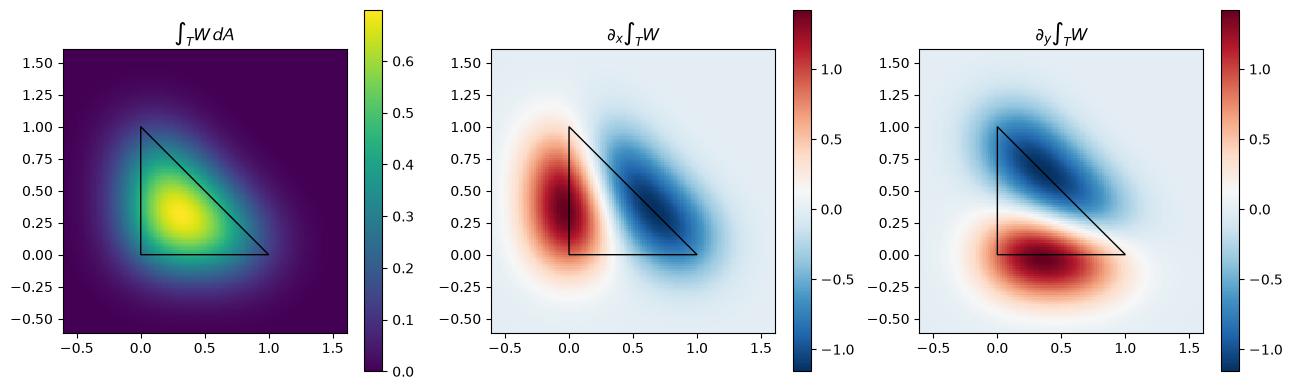

In [2]:

T = np.array([[0.0, 0.0], [1.0, 0.0], [0.0, 1.0]])
xs = np.linspace(-0.6, 1.6, 120); ys = np.linspace(-0.6, 1.6, 120)
X, Y = np.meshgrid(xs, ys); P = np.stack([X.ravel(), Y.ravel()], 1)
V = np.broadcast_to(T, (len(P), 3, 2))
val = np2d.value(V, P, "w4").reshape(X.shape)
g = np2d.gradient(V, P, "w4").reshape(X.shape + (2,))
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
im = ax[0].pcolormesh(X, Y, val, shading="auto"); ax[0].set_title(r"$\int_T W\,dA$"); plt.colorbar(im, ax=ax[0])
im = ax[1].pcolormesh(X, Y, g[..., 0], shading="auto", cmap="RdBu_r"); ax[1].set_title(r"$\partial_x\int_T W$"); plt.colorbar(im, ax=ax[1])
im = ax[2].pcolormesh(X, Y, g[..., 1], shading="auto", cmap="RdBu_r"); ax[2].set_title(r"$\partial_y\int_T W$"); plt.colorbar(im, ax=ax[2])
for a in ax: a.fill(*T.T, fill=False, ec="k"); a.set_aspect("equal")
plt.tight_layout(); plt.show()


## 2. Exactness: the 2025 benchmark problems (covering meshes of $[-1,1]^2$, $x=0$, $h=1$)

Constant field → integral 1, gradient 0; field $f=x$ → integral 0, gradient $(1,0)^T$ (the exact answers). Errors of the float64 numpy implementation, the float32 *stable* mode and the
independent 40-digit reference (see `tests/edge/test_paper2025.py`; paper: ~1e-13 analytic, ~1e-10 quadrature of degree 50).

In [3]:

from edge.test_paper2025 import mesh8, mesh96, evaluate_numpy, nodal_x
rows = []
for name, tris in (("8 triangles", mesh8()), ("96 triangles", mesh96())):
    I1, g1 = evaluate_numpy(tris, lambda T: np.ones(3)); I2, g2 = evaluate_numpy(tris, nodal_x)
    I3, g3 = evaluate_numpy(tris, nodal_x, np.float32, stable=(8, 6))
    rows.append((name, abs(I1 - 1), np.abs(g1).max(), abs(I2), max(abs(g2[0] - 1), abs(g2[1])), abs(I3), max(abs(g3[0] - 1), abs(g3[1]))))
print("| mesh | f64: const int | const grad | linear int | linear grad | f32: linear int | linear grad |")
for r in rows: print(f"| {r[0]} | " + " | ".join(f"{v:.1e}" for v in r[1:]) + " |")


| mesh | f64: const int | const grad | linear int | linear grad | f32: linear int | linear grad |
| 8 triangles | 0.0e+00 | 5.6e-17 | 0.0e+00 | 0.0e+00 | 0.0e+00 | 3.0e-08 |
| 96 triangles | 1.6e-14 | 3.9e-13 | 8.9e-15 | 1.8e-13 | 1.4e-08 | 1.6e-07 |


## 3. FEM nodal weights and conditioning for elements much smaller than h

Plain monomial re-expansion loses $(d/L)^{p+1}$ digits for a far element of size $L$; the exact remedies (inner potentials for elements around $x$, Gauss on far elements) keep the error at machine
precision for every $L/h$ (p = 3, w4, relative error of the nodal weights).

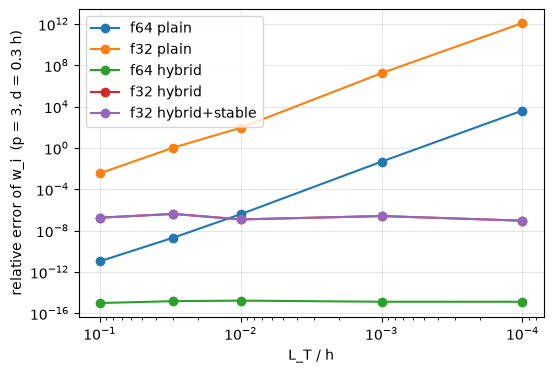

In [4]:

rows = fem_study.study("w4", verbose=False)
sel = [(r[0], r[1], r[2], r[4], r[5], r[6], r[7], r[8]) for r in rows if r[1] == 3 and r[0].startswith("d = 0.3")]
Ls = [r[2] for r in sel]
plt.figure(figsize=(6, 4))
for k, lab in zip(range(3, 8), ["f64 plain", "f32 plain", "f64 hybrid", "f32 hybrid", "f32 hybrid+stable"]):
    plt.loglog(Ls, [max(r[k], 1e-17) for r in sel], "o-", label=lab)
plt.xlabel("L_T / h"); plt.ylabel("relative error of w_i  (p = 3, d = 0.3 h)"); plt.legend(); plt.gca().invert_xaxis(); plt.grid(alpha=.3); plt.show()


## 4. Tier map for a convex disk obstacle ($d=0.3h$): which model for which size?

Tier 4 (series) for small obstacles, tier 3 (curvature expansion) for large ones, exact elements (polygon / curved arcs) in the gap; errors against the exact disk.

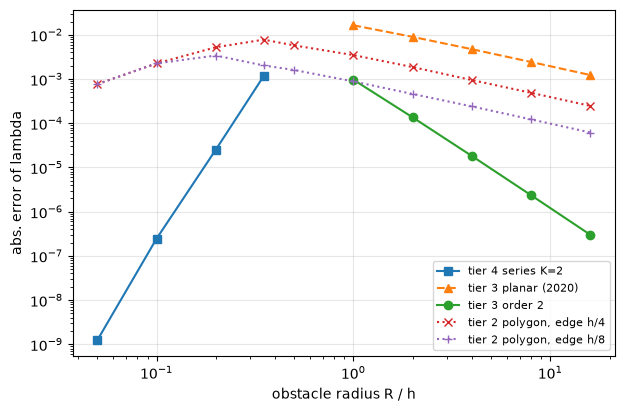

In [5]:

rows = tier_select.run(verbose=False)
R = np.array([r["R"] for r in rows])
plt.figure(figsize=(7, 4.5))
for key, lab, mk in [("t4_K2", "tier 4 series K=2", "s-"), ("t3_0", "tier 3 planar (2020)", "^--"), ("t3_2", "tier 3 order 2", "o-"), ("t2_h4", "tier 2 polygon, edge h/4", "x:"), ("t2_h8", "tier 2 polygon, edge h/8", "+:")]:
    pts = [(r["R"], r[key]) for r in rows if r[key] is not None]
    plt.loglog(*zip(*pts), mk, label=lab)
plt.xlabel("obstacle radius R / h"); plt.ylabel("abs. error of lambda"); plt.legend(fontsize=8); plt.grid(alpha=.3); plt.show()


## 5. Throughput (numpy float64, one thread; Warp CUDA float64 is ~120x faster for the value, `docs/autodiff-and-gpu.md`)

In [6]:

rng = np.random.default_rng(1); N = 200_000
Vr = rng.uniform(-1, 1, (N, 3, 2)); Xr = rng.uniform(-.4, .4, (N, 2))
for what, fn in [("value", lambda: np2d.value(Vr, Xr, "w4")), ("gradient", lambda: np2d.gradient(Vr, Xr, "w4")),
                 ("moment (1,1)", lambda: np2d.moment(Vr, Xr, "w4", (1, 1))), ("shape gradient", lambda: np2d.shape_gradient(Vr, Xr, "w4"))]:
    fn(); t = time.perf_counter(); fn(); print(f"{what:16s} {(time.perf_counter()-t)/N*1e6:6.2f} us per triangle/point pair")


value              3.88 us per triangle/point pair


gradient           2.06 us per triangle/point pair


moment (1,1)       3.24 us per triangle/point pair


shape gradient     2.67 us per triangle/point pair
